# Arquitectura MLP

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando device: {device}")

X_train = np.load('data/X_train_processed.npy')
X_val = np.load('data/X_val_processed.npy')
y_train = np.load('data/y_train.npy') 
y_val = np.load('data/y_val.npy')

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

Usando device: cpu
X_train: (934, 223), X_val: (234, 223)


## Estrategia de división d edatos y validación cruzada

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("Tamaño de validación:", X_val.shape[0], f"({X_val.shape[0]/(X_train.shape[0]+X_val.shape[0])*100:.1f}% del total)")

Tamaño de validación: 234 (20.0% del total)


## Arquitecturas de red consideradas

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.0, batch_norm=False):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


ARCHITECTURES = {
    'shallow':  [64],
    'medium':   [128, 64],
    'deep':     [256, 128, 64, 32],
}

for name, layers in ARCHITECTURES.items():
    m = MLP(X_train.shape[1], layers)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:10s} {str(layers):20s} -> {n_params:,} parámetros")

shallow    [64]                 -> 14,401 parámetros
medium     [128, 64]            -> 36,993 parámetros
deep       [256, 128, 64, 32]   -> 100,609 parámetros


## Hiperparámetros

In [6]:
HYPERPARAMS = {
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 32,
    'max_epochs': 200,
    'patience': 15,      
    'dropout': 0.2,
    'batch_norm': True,
}
HYPERPARAMS

{'lr': 0.001,
 'weight_decay': 0.0001,
 'batch_size': 32,
 'max_epochs': 200,
 'patience': 15,
 'dropout': 0.2,
 'batch_norm': True}

## Técnicas de regularización

In [7]:
def train_model(hidden_layers, hp, X_train, y_train, X_val, y_val, verbose=True):
    model = MLP(X_train.shape[1], hidden_layers,
                dropout=hp['dropout'], batch_norm=hp['batch_norm']).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
    loss_fn = nn.MSELoss()

    Xtr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    Xva_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva_t = torch.tensor(y_val, dtype=torch.float32).to(device)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=hp['batch_size'], shuffle=True)

    history = {'train_rmse': [], 'val_rmse': []}
    best_val_rmse = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(hp['max_epochs']):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            train_rmse = torch.sqrt(loss_fn(model(Xtr_t), ytr_t)).item()
            val_rmse = torch.sqrt(loss_fn(model(Xva_t), yva_t)).item()
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d}  train_rmse(log)={train_rmse:.4f}  val_rmse(log)={val_rmse:.4f}")

        if epochs_no_improve >= hp['patience']:
            if verbose:
                print(f"  Early stopping en epoch {epoch} (mejor val_rmse={best_val_rmse:.4f})")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_rmse

# Entrenamiento de los modelos

In [8]:
results = {}
for name, layers in ARCHITECTURES.items():
    print(f"\nEntrenando arquitectura '{name}' {layers}...")
    model, history, best_val_rmse = train_model(layers, HYPERPARAMS, X_train, y_train, X_val, y_val)
    results[name] = {'model': model, 'history': history, 'best_val_rmse': best_val_rmse}
    print(f"  -> Mejor val_rmse (log): {best_val_rmse:.4f}")


Entrenando arquitectura 'shallow' [64]...
  epoch   0  train_rmse(log)=11.2906  val_rmse(log)=11.3031
  epoch  20  train_rmse(log)=0.5718  val_rmse(log)=1.1718
  Early stopping en epoch 37 (mejor val_rmse=1.0631)
  -> Mejor val_rmse (log): 1.0631

Entrenando arquitectura 'medium' [128, 64]...
  epoch   0  train_rmse(log)=11.5910  val_rmse(log)=11.5823
  epoch  20  train_rmse(log)=0.7540  val_rmse(log)=0.9128
  epoch  40  train_rmse(log)=0.6367  val_rmse(log)=0.7575
  Early stopping en epoch 53 (mejor val_rmse=0.5788)
  -> Mejor val_rmse (log): 0.5788

Entrenando arquitectura 'deep' [256, 128, 64, 32]...
  epoch   0  train_rmse(log)=11.7582  val_rmse(log)=11.7525
  epoch  20  train_rmse(log)=0.7174  val_rmse(log)=0.7541
  epoch  40  train_rmse(log)=0.5658  val_rmse(log)=0.5523
  epoch  60  train_rmse(log)=0.3954  val_rmse(log)=0.4088
  Early stopping en epoch 72 (mejor val_rmse=0.3652)
  -> Mejor val_rmse (log): 0.3652


## Curvas de entrenamiento

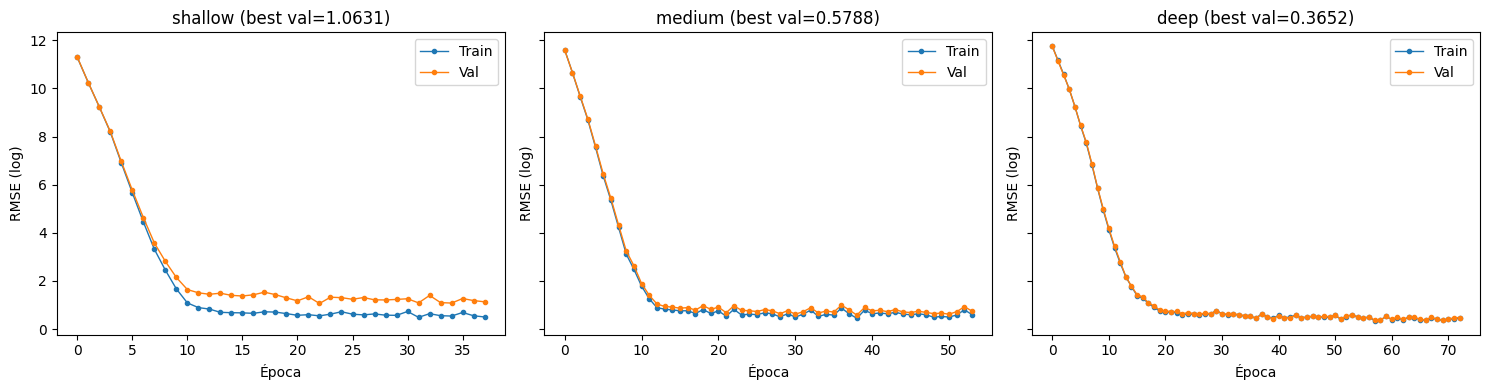

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, r) in zip(axes, results.items()):
    h = r['history']
    epochs = range(len(h['train_rmse']))
    ax.plot(epochs, h['train_rmse'], marker='o', markersize=3, linewidth=1, label='Train')
    ax.plot(epochs, h['val_rmse'], marker='o', markersize=3, linewidth=1, label='Val')
    ax.set_title(f"{name} (best val={r['best_val_rmse']:.4f})")
    ax.set_xlabel('Época')
    ax.set_ylabel('RMSE (log)')
    ax.legend()
plt.tight_layout()
plt.savefig('reports/arquitecturas_curvas.png', dpi=110)
plt.show()

In [11]:
import pandas as pd

summary = pd.DataFrame([
    {'Arquitectura': name, 'Capas ocultas': str(ARCHITECTURES[name]),
     'Val RMSE (log)': r['best_val_rmse'],
     'Val RMSE (USD)': np.expm1(r['best_val_rmse'])}  # aproximación ilustrativa
    for name, r in results.items()
])
summary.sort_values('Val RMSE (log)')

,Arquitectura,Capas ocultas,Val RMSE (log),Val RMSE (USD)
2,deep,"[256, 128, 64, 32]",0.365200,0.440802
1,medium,"[128, 64]",0.578762,0.783829
0,shallow,[64],1.063122,1.895397


## Prueba de hiperparámetros

In [13]:
from itertools import product

FIXED_ARCH = [256, 128, 64, 32] 

param_grid = {
    'lr': [1e-3, 5e-4, 1e-4],
    'dropout': [0.1, 0.2, 0.3],
    'weight_decay': [1e-4, 1e-3],
}

combinations = list(product(param_grid['lr'], param_grid['dropout'], param_grid['weight_decay']))
print(f"Total de combinaciones a evaluar: {len(combinations)}")

Total de combinaciones a evaluar: 18


In [14]:
import time

grid_results = []
start_time = time.time()

for i, (lr, dropout, wd) in enumerate(combinations):
    hp = {
        'lr': lr, 'dropout': dropout, 'weight_decay': wd,
        'batch_size': 32, 'max_epochs': 200, 'patience': 15, 'batch_norm': True,
    }
    t0 = time.time()
    model, history, best_val_rmse = train_model(FIXED_ARCH, hp, X_train, y_train, X_val, y_val)
    elapsed = time.time() - t0
    n_epochs_trained = len(history['train_rmse'])
    final_train_rmse = history['train_rmse'][-1]

    grid_results.append({
        'lr': lr, 'dropout': dropout, 'weight_decay': wd,
        'val_rmse': best_val_rmse, 'train_rmse_final': final_train_rmse,
        'gap': final_train_rmse - best_val_rmse,  
        'epochs': n_epochs_trained, 'time_sec': round(elapsed, 1),
    })
    print(f"[{i+1}/{len(combinations)}] lr={lr:.0e} dropout={dropout} wd={wd:.0e} "
          f"-> val_rmse={best_val_rmse:.4f} ({elapsed:.1f}s, {n_epochs_trained} epochs)")

total_time = time.time() - start_time
print(f"\nTiempo total del grid search: {total_time/60:.1f} minutos")

  epoch   0  train_rmse(log)=11.6043  val_rmse(log)=11.5867
  epoch  20  train_rmse(log)=0.6348  val_rmse(log)=0.6701
  epoch  40  train_rmse(log)=0.3437  val_rmse(log)=0.3547
  Early stopping en epoch 54 (mejor val_rmse=0.3226)
[1/18] lr=1e-03 dropout=0.1 wd=1e-04 -> val_rmse=0.3226 (4.8s, 55 epochs)
  epoch   0  train_rmse(log)=11.7042  val_rmse(log)=11.7200
  epoch  20  train_rmse(log)=0.4614  val_rmse(log)=0.5011
  epoch  40  train_rmse(log)=0.5126  val_rmse(log)=0.5153
  epoch  60  train_rmse(log)=0.3095  val_rmse(log)=0.3225
  Early stopping en epoch 66 (mejor val_rmse=0.2932)
[2/18] lr=1e-03 dropout=0.1 wd=1e-03 -> val_rmse=0.2932 (5.6s, 67 epochs)
  epoch   0  train_rmse(log)=11.8119  val_rmse(log)=11.8303
  epoch  20  train_rmse(log)=0.7627  val_rmse(log)=0.8392
  epoch  40  train_rmse(log)=0.6294  val_rmse(log)=0.6633
  epoch  60  train_rmse(log)=0.4495  val_rmse(log)=0.4974
  Early stopping en epoch 61 (mejor val_rmse=0.3961)
[3/18] lr=1e-03 dropout=0.2 wd=1e-04 -> val_rmse=

In [15]:
results_df = pd.DataFrame(grid_results).sort_values('val_rmse').reset_index(drop=True)
results_df

,lr,dropout,weight_decay,val_rmse,train_rmse_final,gap,epochs,time_sec
0,0.0005,0.1,0.0001,0.279256,0.432704,0.153448,111,9.4
1,0.0010,0.1,0.0010,0.293201,0.283956,-0.009245,67,5.6
2,0.0010,0.1,0.0001,0.322582,0.391533,0.068951,55,4.8
3,0.0005,0.2,0.0001,0.334396,0.329842,-0.004554,129,10.3
4,0.0005,0.2,0.0010,0.362402,0.502631,0.140228,122,10.5
5,0.0010,0.2,0.0001,0.396094,0.456205,0.060111,62,5.0
6,0.0005,0.1,0.0010,0.399827,0.385842,-0.013985,69,5.8
7,0.0010,0.2,0.0010,0.429095,0.435744,0.006649,52,4.2
8,0.0005,0.3,0.0001,0.438107,0.506349,0.068242,177,14.6
9,0.0001,0.1,0.0001,0.441305,0.436356,-0.004950,200,16.7


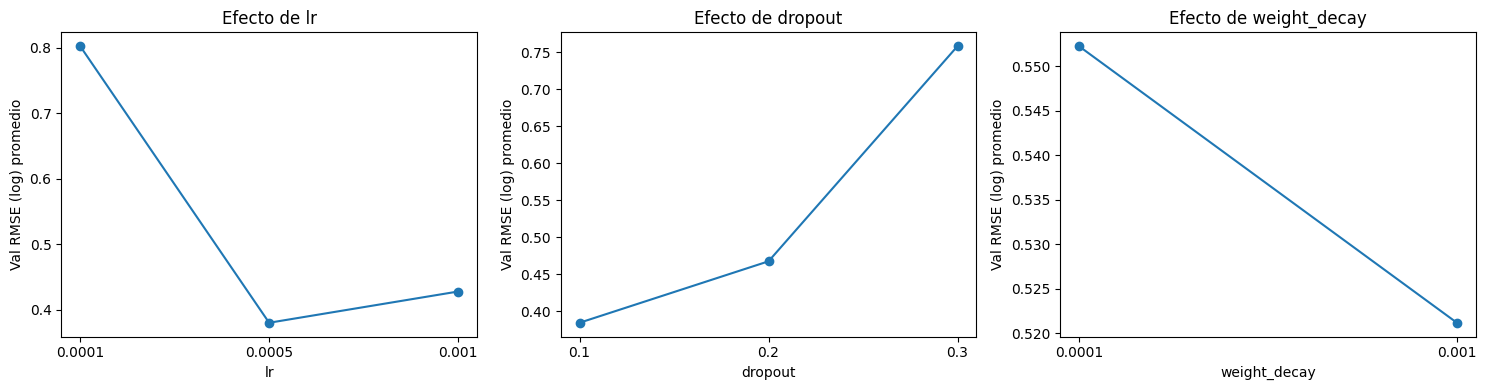

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['lr', 'dropout', 'weight_decay']):
    grouped = results_df.groupby(param)['val_rmse'].mean().sort_index()
    ax.plot(grouped.index.astype(str), grouped.values, marker='o', linewidth=1.5)
    ax.set_xlabel(param)
    ax.set_ylabel('Val RMSE (log) promedio')
    ax.set_title(f'Efecto de {param}')

plt.tight_layout()
plt.savefig('reports/grid_search_efectos.png', dpi=110)
plt.show()

In [18]:
best_config = results_df.iloc[0]
print("Mejor configuración encontrada:")
print(best_config)

Mejor configuración encontrada:
lr                    0.000500
dropout               0.100000
weight_decay          0.000100
val_rmse              0.279256
train_rmse_final      0.432704
gap                   0.153448
epochs              111.000000
time_sec              9.400000
Name: 0, dtype: float64


## Reentrenar el modelo con la mejor configuración

  epoch   0  train_rmse(log)=11.6689  val_rmse(log)=11.6577
  epoch  20  train_rmse(log)=4.2085  val_rmse(log)=4.3134
  epoch  40  train_rmse(log)=0.6297  val_rmse(log)=0.7217
  epoch  60  train_rmse(log)=0.4260  val_rmse(log)=0.4830
  epoch  80  train_rmse(log)=0.2912  val_rmse(log)=0.3172
  epoch 100  train_rmse(log)=0.3438  val_rmse(log)=0.3520
  Early stopping en epoch 117 (mejor val_rmse=0.2821)


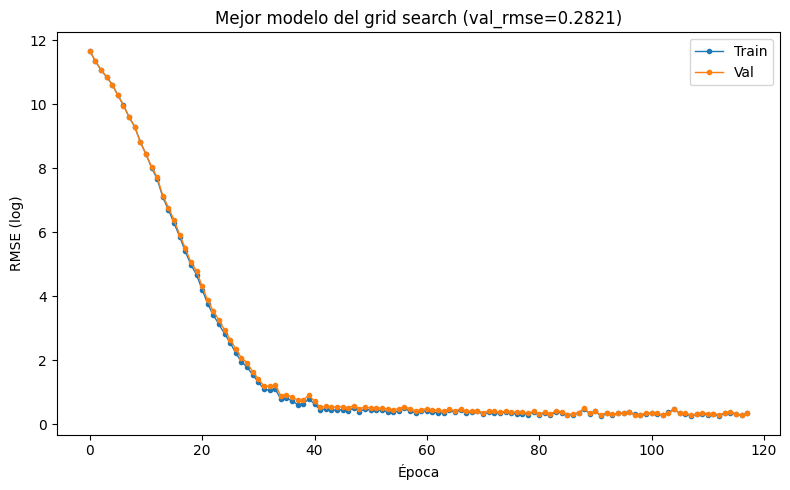

In [20]:
best_hp = {
    'lr': best_config['lr'],
    'dropout': best_config['dropout'],
    'weight_decay': best_config['weight_decay'],
    'batch_size': 32, 'max_epochs': 200, 'patience': 15, 'batch_norm': True,
}

best_model, best_history, best_val_rmse = train_model(
    FIXED_ARCH, best_hp, X_train, y_train, X_val, y_val, verbose=True
)

fig, ax = plt.subplots(figsize=(8, 5))
epochs = range(len(best_history['train_rmse']))
ax.plot(epochs, best_history['train_rmse'], marker='o', markersize=3, linewidth=1, label='Train')
ax.plot(epochs, best_history['val_rmse'], marker='o', markersize=3, linewidth=1, label='Val')
ax.set_xlabel('Época')
ax.set_ylabel('RMSE (log)')
ax.set_title(f'Mejor modelo del grid search (val_rmse={best_val_rmse:.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('reports/mejor_modelo_curvas.png', dpi=110)
plt.show()

In [21]:
torch.save({
    'model_state_dict': best_model.state_dict(),
    'architecture': FIXED_ARCH,
    'hyperparams': best_hp,
    'val_rmse_log': best_val_rmse,
}, 'models/best_mlp_iteracion2.pt')

results_df.to_csv('reports/grid_search_resultados.csv', index=False)
print("Modelo y resultados guardados")

Modelo y resultados guardados
